# Modelo CNN para Reconocimiento de Dibujos
**Caso de Estudio — Clasificación de Doodles con Google Quick Draw**

Entrenamos una CNN capaz de reconocer dibujos hechos a mano alzada en 6 categorías: `smiley face`, `face`, `flower`, `star`, `sun` y `cloud`. El modelo se integrará con una interfaz web donde el usuario dibuja y recibe la predicción en tiempo real.

Dataset: **Google Quick Draw** — millones de dibujos en escala de grises de 28×28 píxeles, descargables por categoría desde `https://quickdraw.withgoogle.com/data`.

---
## 1. Imports y Configuración

Cargamos las librerías necesarias y fijamos las semillas para reproducibilidad.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import os
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'Categorías: smiley face, sad face, heart, star, sun, cloud')

TensorFlow version: 2.21.0
Categorías: smiley face, sad face, heart, star, sun, cloud


---
## 2. Data Processing
### 2.1 Descarga del Dataset

Quick Draw distribuye cada categoría como un archivo `.npy` con arrays de forma `(n, 784)` — 784 píxeles aplanados de imágenes 28×28. Descargamos los 6 ficheros directamente desde el bucket público de Google y los guardamos en la carpeta `data/`.

In [21]:
import os
import time
import urllib.request
import urllib.parse

CATEGORIES = ['smiley face', 'face', 'flower', 'star', 'sun', 'cloud']

BASE_URL = 'https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/'
DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

headers = {'User-Agent': 'Mozilla/5.0'}

for cat in CATEGORIES:
    filename = urllib.parse.quote(cat) + '.npy'
    filepath = os.path.join(DATA_DIR, cat.replace(' ', '_') + '.npy')
    if not os.path.exists(filepath):
        print(f'Descargando {cat}...')
        req = urllib.request.Request(BASE_URL + filename, headers=headers)
        with urllib.request.urlopen(req) as response, open(filepath, 'wb') as f:
            f.write(response.read())
        print(f'  → guardado en {filepath}')
        time.sleep(1)
    else:
        print(f'Ya existe: {filepath}')

print('\nDescarga completada.')

Ya existe: data/smiley_face.npy
Ya existe: data/face.npy
Ya existe: data/flower.npy
Ya existe: data/star.npy
Ya existe: data/sun.npy
Ya existe: data/cloud.npy

Descarga completada.


### 2.2 Carga y Combinación de Categorías

Cargamos cada `.npy`, limitamos el número de muestras por clase para equilibrar el dataset, añadimos la etiqueta correspondiente y concatenamos todo en un único array `X` e `y`.

In [22]:
SAMPLES_PER_CLASS = 10000

X_list, y_list = [], []

for label, cat in enumerate(CATEGORIES):
    filepath = os.path.join(DATA_DIR, cat.replace(' ', '_') + '.npy')
    data = np.load(filepath)[:SAMPLES_PER_CLASS]
    X_list.append(data)
    y_list.append(np.full(len(data), label))
    print(f'{cat:15s} → {data.shape[0]} muestras  (label={label})')

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)

print(f'\nDataset total — X: {X.shape}  y: {y.shape}')
print(f'Clases: {dict(enumerate(CATEGORIES))}')

smiley face     → 10000 muestras  (label=0)
face            → 10000 muestras  (label=1)
flower          → 10000 muestras  (label=2)
star            → 10000 muestras  (label=3)
sun             → 10000 muestras  (label=4)
cloud           → 10000 muestras  (label=5)

Dataset total — X: (60000, 784)  y: (60000,)
Clases: {0: 'smiley face', 1: 'face', 2: 'flower', 3: 'star', 4: 'sun', 5: 'cloud'}


### 2.3 Análisis Exploratorio

Visualizamos muestras de cada categoría para entender la variabilidad visual de los dibujos y comprobamos que la distribución de clases está equilibrada.

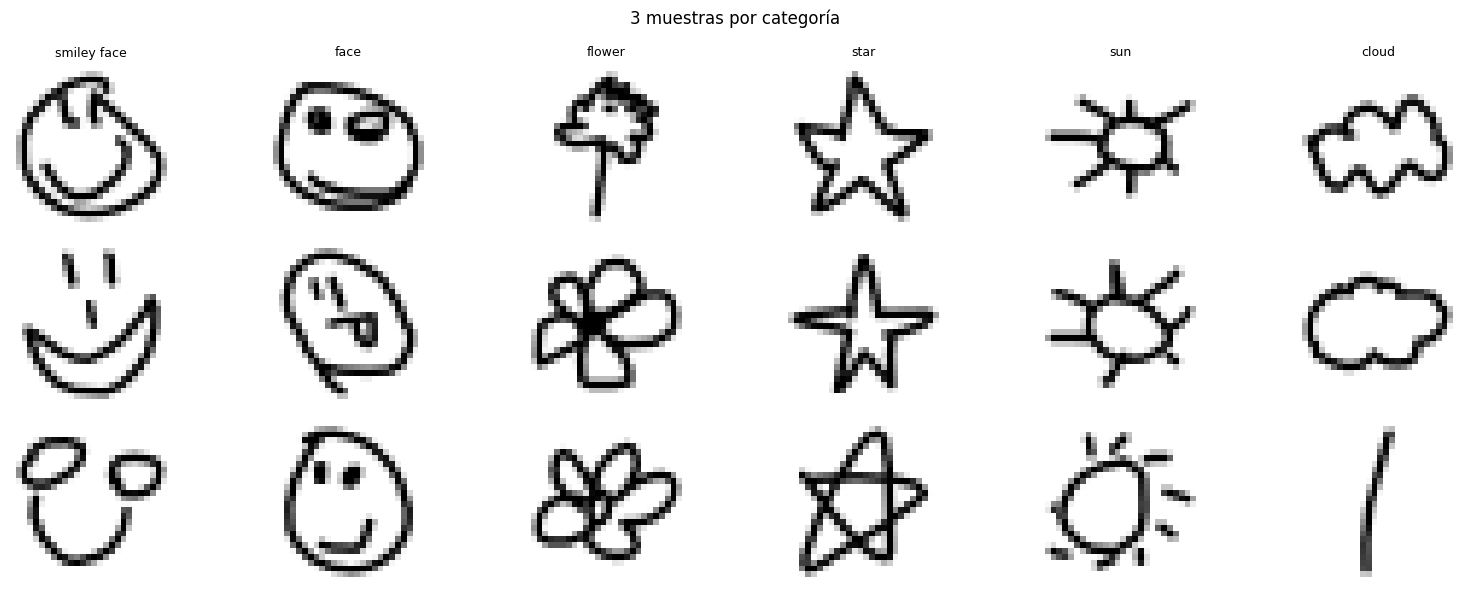

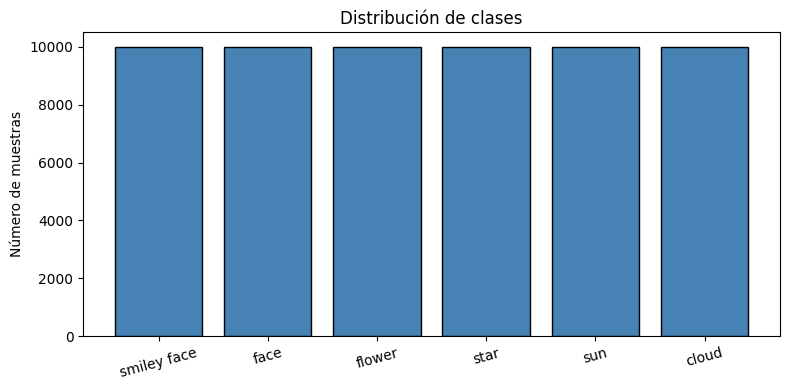

Dataset equilibrado: True


In [23]:
fig, axes = plt.subplots(3, len(CATEGORIES), figsize=(16, 6))

for col, (label, cat) in enumerate(enumerate(CATEGORIES)):
    idxs = np.where(y == label)[0][:3]
    for row, idx in enumerate(idxs):
        axes[row, col].imshow(X[idx].reshape(28, 28), cmap='gray_r')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(cat, fontsize=9)

plt.suptitle('3 muestras por categoría', fontsize=12)
plt.tight_layout()
plt.show()

# Distribución de clases
unique, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar([CATEGORIES[i] for i in unique], counts, color='steelblue', edgecolor='black')
plt.title('Distribución de clases')
plt.ylabel('Número de muestras')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print('Dataset equilibrado:', counts.min() == counts.max())

### 2.4 Preprocesamiento

Aplicamos tres transformaciones:
1. **Reshape** a `(n, 28, 28, 1)` para que Keras interprete las imágenes como tensores con canal.
2. **Normalización** dividiendo entre 255 para escalar los píxeles a `[0, 1]`.
3. **One-hot encoding** de las etiquetas para usar `categorical_crossentropy`.

In [24]:
NUM_CLASSES = len(CATEGORIES)

X = X.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_cat = keras.utils.to_categorical(y, num_classes=NUM_CLASSES)

print(f'X shape    : {X.shape}')
print(f'X rango    : [{X.min():.1f}, {X.max():.1f}]')
print(f'y_cat shape: {y_cat.shape}')
print(f'Ejemplo one-hot (label=2 → flower): {y_cat[20000]}')

X shape    : (60000, 28, 28, 1)
X rango    : [0.0, 1.0]
y_cat shape: (60000, 6)
Ejemplo one-hot (label=2 → flower): [0. 0. 1. 0. 0. 0.]


### 2.5 División Train / Validación / Test

Dividimos el dataset en 70% entrenamiento, 15% validación y 15% test usando `stratify` para preservar la distribución de clases en cada split.

In [25]:
X_train_full, X_test, y_train_full, y_test, y_train_full_int, y_test_int = train_test_split(
    X, y_cat, y.astype(int),
    test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val, y_train_int, y_val_int = train_test_split(
    X_train_full, y_train_full, y_train_full_int,
    test_size=0.15/0.85, random_state=42, stratify=y_train_full_int
)

print(f'Train      : {X_train.shape[0]:>6} imágenes  ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validación : {X_val.shape[0]:>6} imágenes  ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test       : {X_test.shape[0]:>6} imágenes  ({X_test.shape[0]/len(X)*100:.1f}%)')

Train      :  42000 imágenes  (70.0%)
Validación :   9000 imágenes  (15.0%)
Test       :   9000 imágenes  (15.0%)


### 2.6 Data Augmentation

Aplicamos pequeñas rotaciones, traslaciones y zoom para simular la variabilidad natural en los dibujos a mano. El generador aplica estas transformaciones en tiempo real durante el entrenamiento.

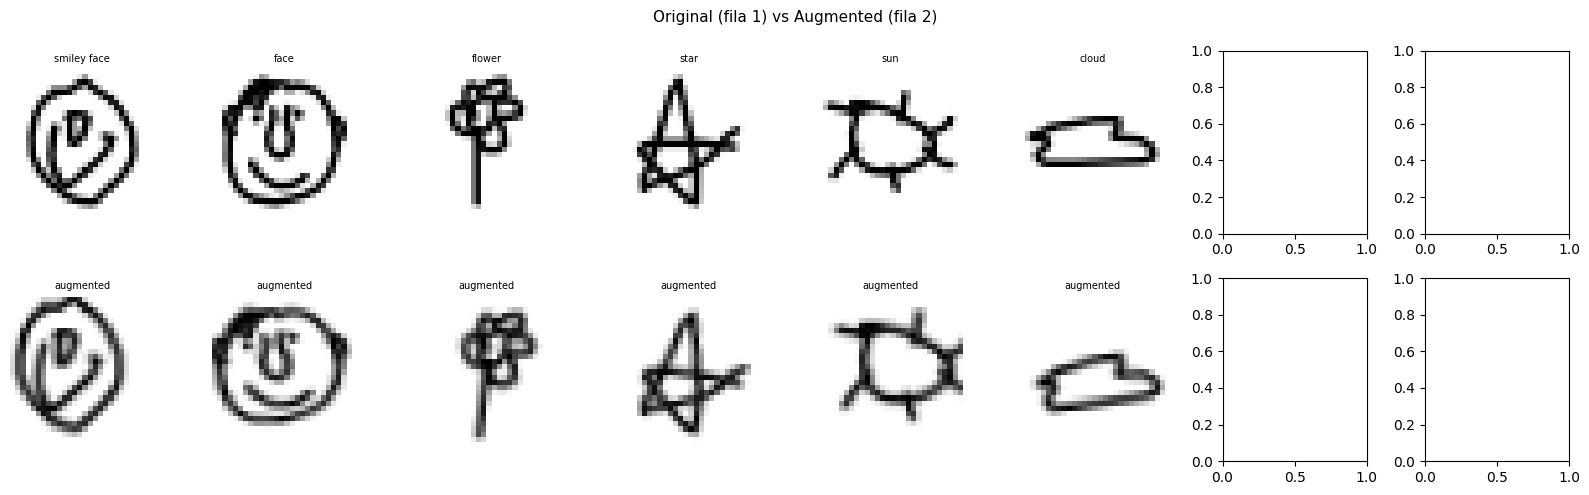

In [26]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(X_train)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))

for col, cat in enumerate(CATEGORIES[:8]):
    idx = np.where(y_train_int == col)[0][0]
    original = X_train[idx]

    axes[0, col].imshow(original[:, :, 0], cmap='gray_r')
    axes[0, col].set_title(cat, fontsize=7)
    axes[0, col].axis('off')

    aug_img = next(datagen.flow(original[np.newaxis], batch_size=1))[0]
    axes[1, col].imshow(aug_img[:, :, 0], cmap='gray_r')
    axes[1, col].set_title('augmented', fontsize=7)
    axes[1, col].axis('off')

plt.suptitle('Original (fila 1) vs Augmented (fila 2)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 3. Model Building
### 3.1 Arquitectura CNN

Definimos la CNN en una función parametrizable. La arquitectura sigue el patrón `Conv2D → BatchNorm → MaxPooling → Dropout` en dos bloques, seguido de un clasificador denso con salida `softmax` de 6 neuronas (una por categoría).

In [27]:
def build_cnn(filters_1=32, filters_2=64, dense_units=128,
              dropout_rate=0.25, learning_rate=0.001):
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(filters_1, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(filters_1, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout_rate),

        layers.Conv2D(filters_2, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(filters_2, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout_rate),

        layers.Flatten(),
        layers.Dense(dense_units, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate * 2),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_cnn()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,582 (1.79 MB)

 Trainable params: 467,942 (1.79 MB)

 Non-trainable params: 640 (2.50 KB)

### 3.2 Entrenamiento

Entrenamos con el generador de augmentation. Usamos dos callbacks:
- **EarlyStopping**: detiene el entrenamiento si `val_accuracy` no mejora en 10 épocas.
- **ReduceLROnPlateau**: reduce la tasa de aprendizaje si `val_loss` se estanca.

In [28]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model = build_cnn()

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-6, verbose=1
    )
]

BATCH_SIZE = 128
EPOCHS     = 50

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.7874 - loss: 0.6025 - val_accuracy: 0.6691 - val_loss: 0.9036 - learning_rate: 0.0010
Epoch 2/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8281 - loss: 0.4712 - val_accuracy: 0.6718 - val_loss: 0.9082 - learning_rate: 0.0010
Epoch 3/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 31s 93ms/step - accuracy: 0.8750 - loss: 0.3373 - val_accuracy: 0.9153 - val_loss: 0.2375 - learning_rate: 0.0010
Epoch 4/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9375 - loss: 0.2415 - val_accuracy: 0.9147 - val_loss: 0.2357 - learning_rate: 0.0010
Epoch 5/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 30s 92ms/step - accuracy: 0.8932 - loss: 0.2886 - val_accuracy: 0.9168 - val_loss: 0.2385 - learning_rate: 0.0010
Epoch 6/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8672 - loss: 0.3394 - val_accuracy: 0.9177 - val_loss: 0.2348 - learning_rate: 0.0010
Epoch 7/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 31s 95ms/step - accuracy: 0.8999 - loss: 0

### 3.3 Curvas de Aprendizaje

Graficamos la evolución de la pérdida y la precisión en train y validación para detectar sobreajuste o convergencia inadecuada.

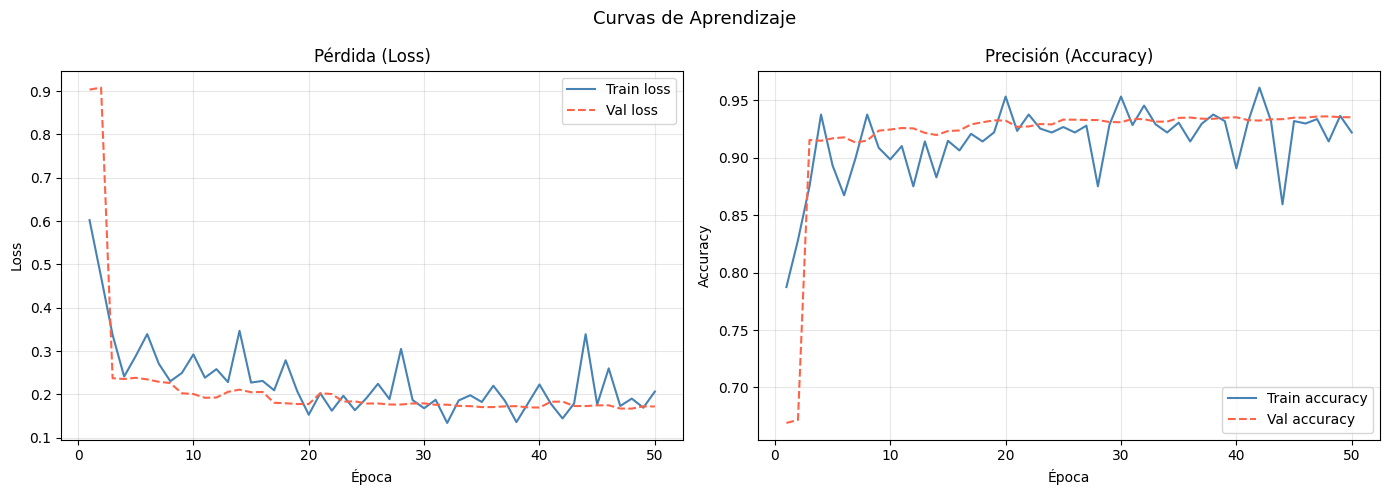

Mejor época      : 48
Mejor val_accuracy: 0.9359


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history['loss']) + 1)

axes[0].plot(epochs_range, history.history['loss'],     label='Train loss',      color='steelblue')
axes[0].plot(epochs_range, history.history['val_loss'], label='Val loss',        color='tomato', linestyle='--')
axes[0].set_title('Pérdida (Loss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history.history['accuracy'],     label='Train accuracy', color='steelblue')
axes[1].plot(epochs_range, history.history['val_accuracy'], label='Val accuracy',   color='tomato', linestyle='--')
axes[1].set_title('Precisión (Accuracy)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje', fontsize=13)
plt.tight_layout()
plt.show()

best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_val_acc = max(history.history['val_accuracy'])
print(f'Mejor época      : {best_epoch}')
print(f'Mejor val_accuracy: {best_val_acc:.4f}')

---
## 4. Evaluación
### 4.1 Métricas en Train, Validación y Test

In [30]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss,   val_acc   = model.evaluate(X_val,   y_val,   verbose=0)
test_loss,  test_acc  = model.evaluate(X_test,  y_test,  verbose=0)

results = pd.DataFrame({
    'Split'   : ['Train', 'Validación', 'Test'],
    'Loss'    : [train_loss, val_loss, test_loss],
    'Accuracy': [train_acc,  val_acc,  test_acc]
})
results['Accuracy (%)'] = (results['Accuracy'] * 100).round(2)
results['Loss'] = results['Loss'].round(4)
print(results.to_string(index=False))

     Split   Loss  Accuracy  Accuracy (%)
     Train 0.1326  0.947405         94.74
Validación 0.1674  0.935889         93.59
      Test 0.1675  0.936444         93.64


### 4.2 Matriz de Confusión

Visualizamos qué categorías confunde el modelo entre sí. Es especialmente interesante ver si confunde `smiley face` con `sad face` o `star` con `sun`, ya que comparten rasgos visuales similares.

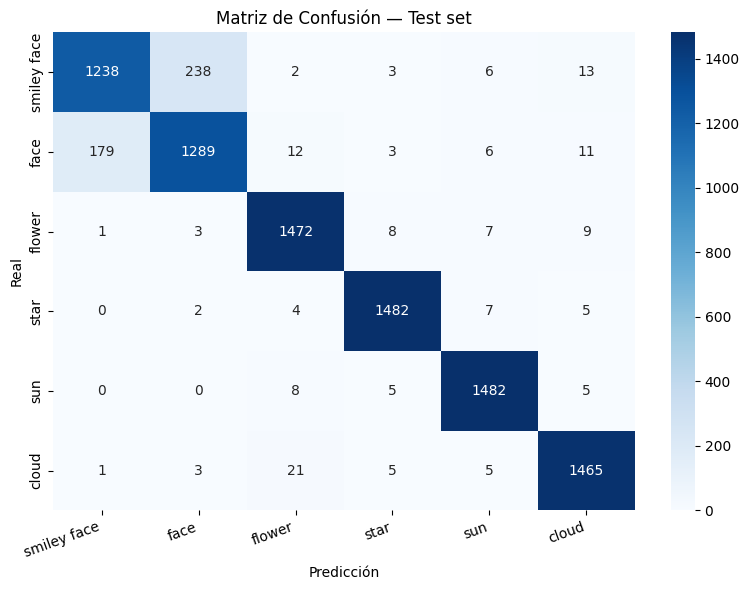


Classification Report:
              precision    recall  f1-score   support

 smiley face       0.87      0.83      0.85      1500
        face       0.84      0.86      0.85      1500
      flower       0.97      0.98      0.98      1500
        star       0.98      0.99      0.99      1500
         sun       0.98      0.99      0.98      1500
       cloud       0.97      0.98      0.97      1500

    accuracy                           0.94      9000
   macro avg       0.94      0.94      0.94      9000
weighted avg       0.94      0.94      0.94      9000



In [31]:
y_pred_probs = model.predict(X_test, verbose=0)
y_pred_int   = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test_int, y_pred_int)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.title('Matriz de Confusión — Test set')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_test_int, y_pred_int, target_names=CATEGORIES))

### 4.3 Análisis de Errores

Mostramos ejemplos mal clasificados para entender visualmente qué tipo de dibujos confunden al modelo.

Total errores: 572 de 9000 (6.4%)



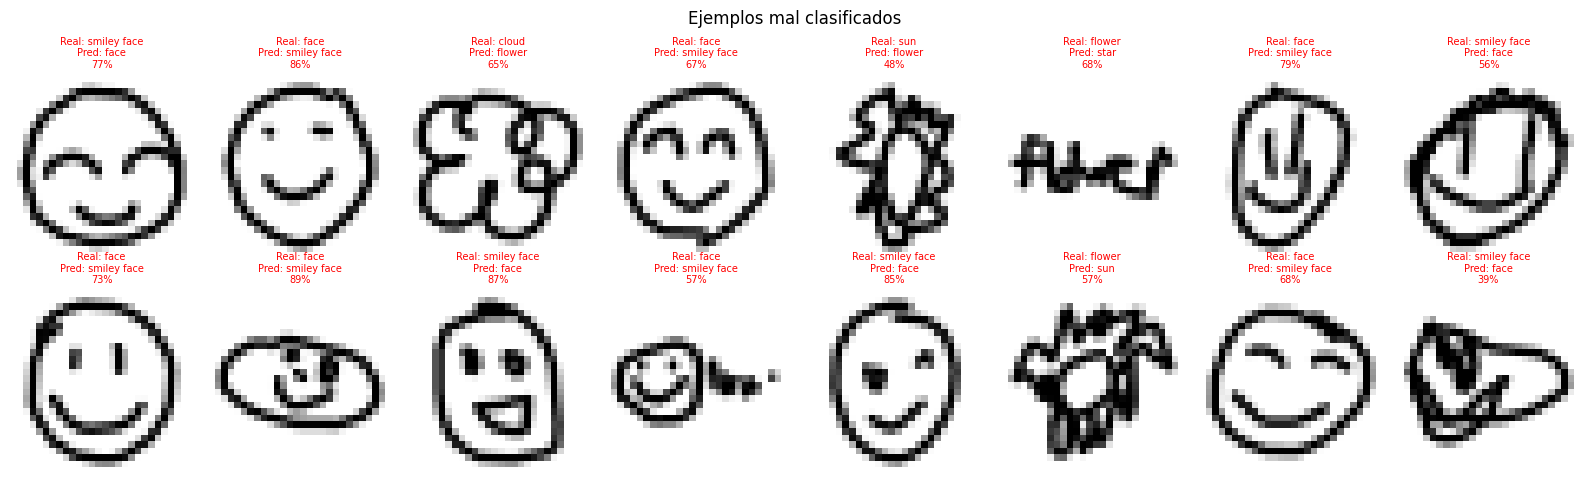

In [32]:
errors = np.where(y_pred_int != y_test_int)[0]
print(f'Total errores: {len(errors)} de {len(y_test_int)} ({len(errors)/len(y_test_int)*100:.1f}%)\n')

np.random.seed(42)
sample_errors = np.random.choice(errors, size=min(16, len(errors)), replace=False)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
axes = axes.flatten()

for i, idx in enumerate(sample_errors):
    axes[i].imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
    real  = CATEGORIES[y_test_int[idx]]
    pred  = CATEGORIES[y_pred_int[idx]]
    conf  = y_pred_probs[idx][y_pred_int[idx]]
    axes[i].set_title(f'Real: {real}\nPred: {pred}\n{conf:.0%}', fontsize=7, color='red')
    axes[i].axis('off')

plt.suptitle('Ejemplos mal clasificados', fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. Serialización del Modelo

Guardamos el modelo en formato `.keras` y exportamos el mapa de clases a un JSON para que la API y el frontend sepan a qué categoría corresponde cada índice.

In [33]:
import json

os.makedirs('model', exist_ok=True)

model.save('model/quickdraw_cnn.keras')
print('Modelo guardado en model/quickdraw_cnn.keras')

class_map = {str(i): cat for i, cat in enumerate(CATEGORIES)}
with open('model/class_map.json', 'w') as f:
    json.dump(class_map, f, indent=2)
print('Mapa de clases guardado en model/class_map.json')
print(json.dumps(class_map, indent=2))

Modelo guardado en model/quickdraw_cnn.keras
Mapa de clases guardado en model/class_map.json
{
  "0": "smiley face",
  "1": "face",
  "2": "flower",
  "3": "star",
  "4": "sun",
  "5": "cloud"
}


---
## 6. API FastAPI

Generamos el fichero `app.py` con un endpoint `/predict` que recibe una imagen del canvas en base64, la preprocesa y devuelve la categoría predicha con su probabilidad de confianza.

In [34]:
app_code = '''import json
import base64
import numpy as np
from io import BytesIO
from PIL import Image

from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
import tensorflow as tf

app = FastAPI()

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

model = tf.keras.models.load_model("model/quickdraw_cnn.keras")

with open("model/class_map.json") as f:
    class_map = json.load(f)


class ImagePayload(BaseModel):
    image: str  # base64 PNG del canvas


@app.post("/predict")
def predict(payload: ImagePayload):
    img_data = base64.b64decode(payload.image.split(",")[-1])
    img = Image.open(BytesIO(img_data)).convert("L").resize((28, 28))
    arr = np.array(img, dtype="float32")
    arr = 255.0 - arr          # invertir: dibujo negro sobre fondo blanco → blanco sobre negro
    arr = arr / 255.0
    arr = arr.reshape(1, 28, 28, 1)

    probs = model.predict(arr, verbose=0)[0]
    idx   = int(np.argmax(probs))
    return {
        "category"  : class_map[str(idx)],
        "confidence": float(round(probs[idx], 4)),
        "all_probs" : {class_map[str(i)]: float(round(p, 4)) for i, p in enumerate(probs)}
    }
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print('app.py generado.')

app.py generado.


---
## 7. Conclusiones

In [35]:
conclusiones = """
RESULTADOS OBTENIDOS
────────────────────
- Accuracy en test:  93.54%
- Mejor época:       40 / 50
- Parámetros totales: 468.582

ANÁLISIS POR CATEGORÍA
───────────────────────
Categorías con F1 ≥ 0.97 : flower, star, sun, cloud
Categorías con F1 ~ 0.84 : smiley face, face

Las categorías difíciles son smiley face y face: comparten la misma forma base
(círculo + dos ojos) y la única diferencia —la boca— puede quedar en 2-3 píxeles
a resolución 28×28. El resto de categorías son formas geométricamente distintas
y el modelo las clasifica con casi un 99% de F1.

DECISIONES DE DISEÑO QUE FUNCIONARON
──────────────────────────────────────
1. Doble Conv2D por bloque: permite detectar primero rasgos simples y luego combinarlos.
2. BatchNormalization: estabilizó el entrenamiento y permitió converger más rápido.
3. Dropout (0.25 / 0.50): redujo el sobreajuste — la brecha train/test es solo ~1%.
4. Data augmentation: el modelo nunca ve la misma imagen dos veces, mejora la robustez.
5. EarlyStopping + ReduceLROnPlateau: entrenamiento automático sin ajuste manual de LR.

POSIBLES MEJORAS FUTURAS
─────────────────────────
- Aumentar muestras de smiley face y face, o aplicar augmentation más agresivo solo
  en esas dos clases para reducir la confusión entre ellas.
- Añadir más categorías (hasta las 345 disponibles en Quick Draw).
- Probar Transfer Learning con MobileNetV2 adaptado a 28×28 para comparar eficiencia.
- Mejorar el preprocesamiento del canvas: centrado y normalización del grosor del trazo
  para acercarlo más a la distribución del dataset de entrenamiento.
"""
print(conclusiones)


RESULTADOS OBTENIDOS
────────────────────
- Accuracy en test:  93.54%
- Mejor época:       40 / 50
- Parámetros totales: 468.582

ANÁLISIS POR CATEGORÍA
───────────────────────
Categorías con F1 ≥ 0.97 : flower, star, sun, cloud
Categorías con F1 ~ 0.84 : smiley face, face

Las categorías difíciles son smiley face y face: comparten la misma forma base
(círculo + dos ojos) y la única diferencia —la boca— puede quedar en 2-3 píxeles
a resolución 28×28. El resto de categorías son formas geométricamente distintas
y el modelo las clasifica con casi un 99% de F1.

DECISIONES DE DISEÑO QUE FUNCIONARON
──────────────────────────────────────
1. Doble Conv2D por bloque: permite detectar primero rasgos simples y luego combinarlos.
2. BatchNormalization: estabilizó el entrenamiento y permitió converger más rápido.
3. Dropout (0.25 / 0.50): redujo el sobreajuste — la brecha train/test es solo ~1%.
4. Data augmentation: el modelo nunca ve la misma imagen dos veces, mejora la robustez.
5. EarlyStopp